In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [4]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv")

In [5]:
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [6]:
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='str')

In [7]:
df.dtypes

Region                                     str
Date                                       str
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                   str
dtype: object

In [11]:
import datetime as dt
df['Year'] = pd.to_datetime(df['Date']).dt.year
df['Month'] = pd.to_datetime(df['Date']).dt.month
df[['Year','Month']].dtypes

Year     int32
Month    int32
dtype: object

Q1 Let's try to understand the change in average estimated fire area over time"

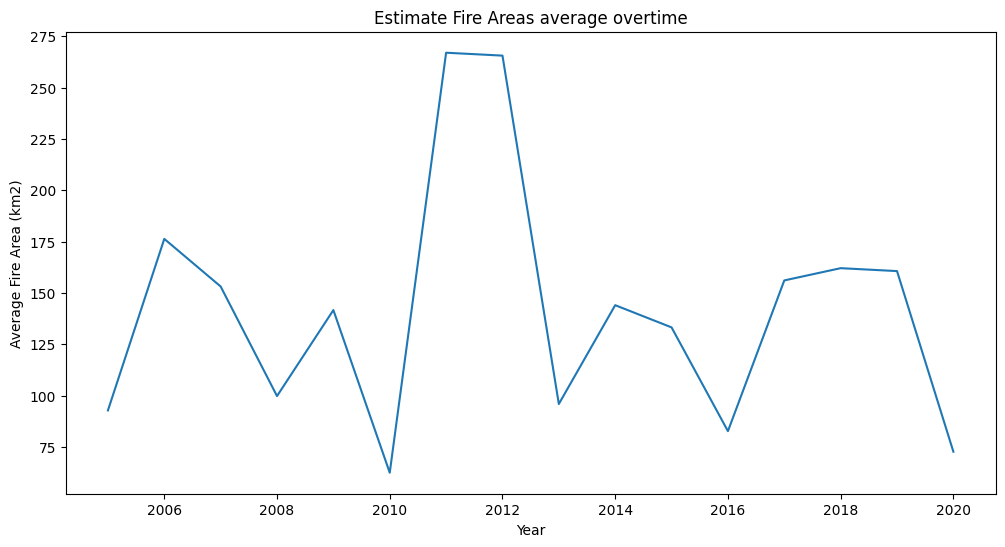

In [ ]:
sol = df.groupby('Year')['Estimated_fire_area'].mean()
plt.figure(figsize=(12,6))
plt.plot(sol.index,sol.values)
plt.xlabel('Year')
plt.ylabel('Average Fire Area (km2)')
plt.title('Estimate Fire Areas average overtime')
plt.show()

Peak is in 2010-2013. Lets Narrow our sample size to see in months what happened here

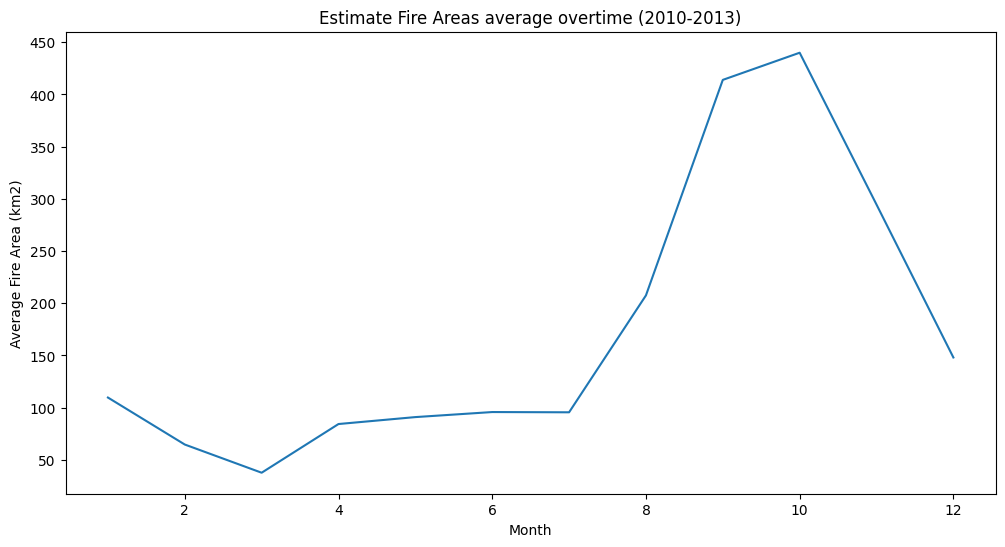

In [24]:
sol = df[df['Year'].between(2010,2013)].groupby('Month')['Estimated_fire_area'].mean()
sol
plt.figure(figsize=(12,6))
plt.plot(sol.index,sol.values)
plt.xlabel('Month')
plt.ylabel('Average Fire Area (km2)')
plt.title('Estimate Fire Areas average overtime (2010-2013)')
plt.show()

Let's have an insight on the distribution of mean estimated fire brightness across the region.

In [25]:
df['Region'].unique()

<ArrowStringArray>
['NSW', 'NT', 'QL', 'SA', 'TA', 'VI', 'WA']
Length: 7, dtype: str

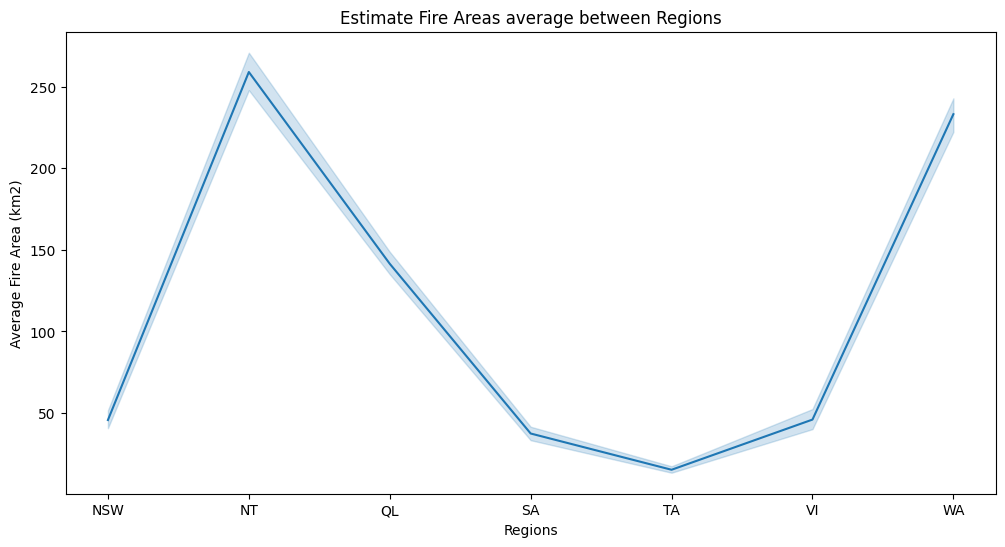

In [31]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Region', y='Estimated_fire_area')
plt.xlabel('Regions')
plt.ylabel('Average Fire Area (km2)')
plt.title('Estimate Fire Areas average between Regions')
plt.show()

Find Portions of Fires Across Regions

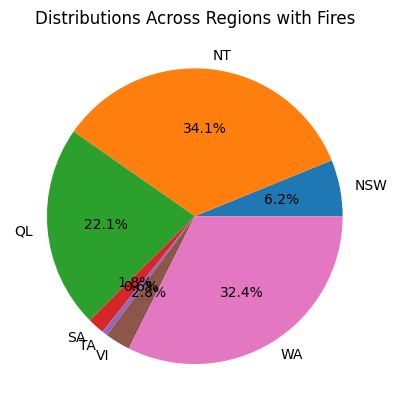

In [43]:
sol = df.groupby('Region')['Count'].sum()
plt.pie(sol, labels=sol.index, autopct='%1.1f%%')
plt.title('Distributions Across Regions with Fires')
plt.show()

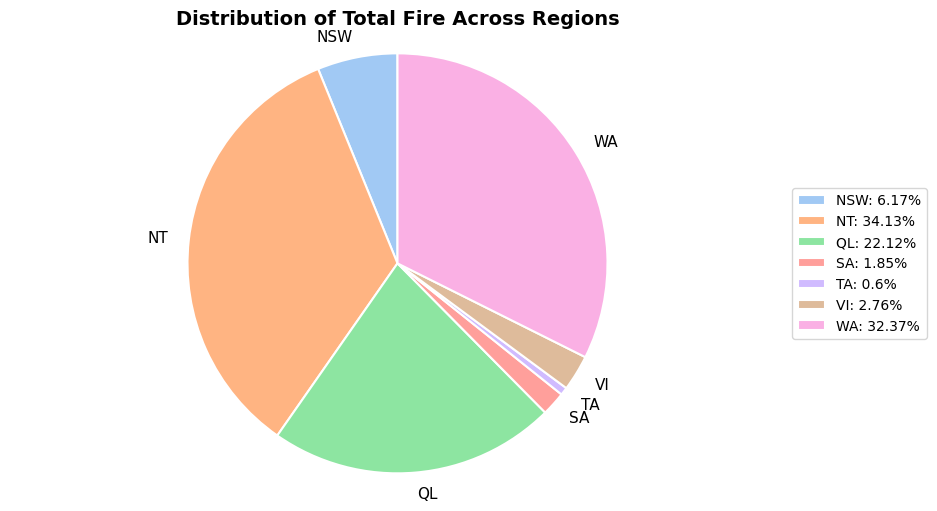

In [50]:
## Lets Prettify it
plt.figure(figsize=(10,6))

colors = sns.color_palette('pastel')

plt.pie(sol,
        labels=sol.index,
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 11})

plt.title('Distribution of Total Fire Across Regions', fontsize=14, fontweight='bold')
plt.legend([f'{i}: {round(k/sol.sum()*100, 2)}%' for i, k in zip(sol.index, sol)],
           loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.axis('equal')  # ensures the pie is a perfect circle, not an oval
plt.show()

Let's try to develop a histogram of the mean estimated fire brightness

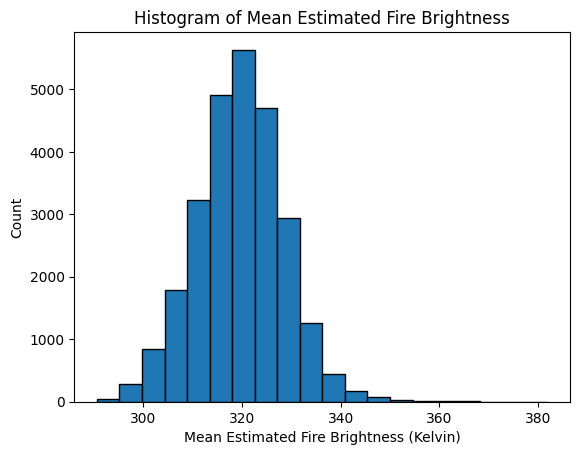

In [53]:
plt.hist(x=df['Mean_estimated_fire_brightness'], bins=20, edgecolor='black')
plt.xlabel('Mean Estimated Fire Brightness (Kelvin)')
plt.ylabel('Count')
plt.title('Histogram of Mean Estimated Fire Brightness')
plt.show()

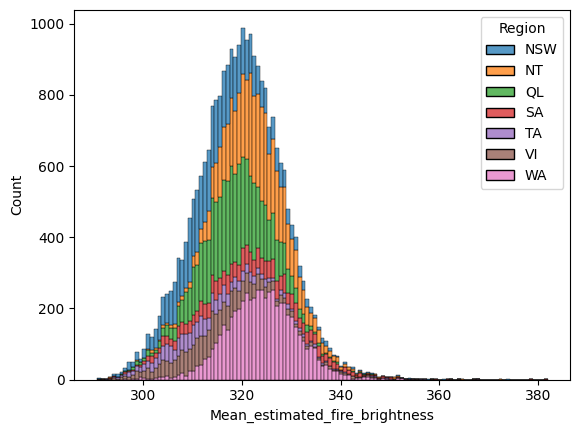

In [ ]:
sns.histplot(data=df,x='Mean_estimated_fire_brightness', hue='Region', multiple='stack')
plt.show()

Let's try to find if there is any correlation between mean estimated fire radiative power and mean confidence level?

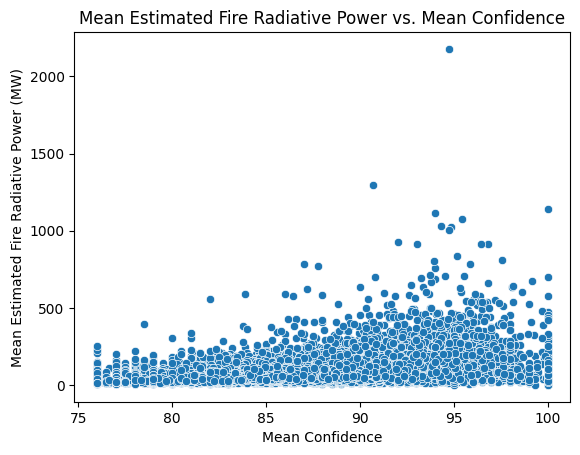

In [62]:
sns.scatterplot(data=df, x='Mean_confidence', y='Mean_estimated_fire_radiative_power')
plt.ylabel('Mean Estimated Fire Radiative Power (MW)')
plt.xlabel('Mean Confidence')
plt.title('Mean Estimated Fire Radiative Power vs. Mean Confidence')
plt.show()

Let's mark these seven regions on the Map of Australia

In [59]:
region_data = {'region':['NSW','QL','SA','TA','VI','WA','NT'], 'Lat':[-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411], 
               'Lon':[147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]}
reg=pd.DataFrame(region_data)
reg

,region,Lat,Lon
0,NSW,-31.875984,147.286949
1,QL,-22.164678,144.584490
2,SA,-30.534367,135.630121
3,TA,-42.035067,146.636689
4,VI,-36.598610,144.678005
5,WA,-25.230300,121.018725
6,NT,-19.491411,132.550964


In [ ]:
# instantiate a feature group 
aus_reg = folium.map.FeatureGroup()

# Create a Folium map centered on Australia
Aus_map = folium.Map(location=[-25, 135], zoom_start=4)

# loop through the region and add to feature group
for lat, lng, lab in zip(reg.Lat, reg.Lon, reg.region):
    aus_reg.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            popup=lab,
            radius=5, # define how big you want the circle markers to be
            color='red',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6
        )
    )

# add incidents to map
Aus_map.add_child(aus_reg)